# Proyecto Final — Deep Learning## Clasificación automática de productos de moda con CNN (Fashion-MNIST)**Estudiante:** Solís Huayanay, Epifanía Angélica****Curso:** Modelos de Deep Learning — CENTRUM PUCP**Fecha:** Mayo 2026---### ContextoEn el comercio electrónico y los sistemas de inventario retail, **clasificar automáticamente las imágenes de productos** es una tarea operativa frecuente: cuando un comerciante sube una foto, la plataforma debería categorizarla sin requerir etiquetado manual. Esto reduce costos de catalogación, acelera la publicación de nuevos productos y mejora la experiencia de búsqueda del usuario.### Problema y objetivo **Problema:** clasificación multiclase (10 categorías) de imágenes de prendas de vestir y accesorios.**Objetivo:** entrenar una **red neuronal convolucional (CNN)** desde cero que clasifique correctamente imágenes de prendas en 10 categorías, evaluar su rendimiento mediante métricas estándar (accuracy, F1-score por clase, matriz de confusión) y discutir el valor del modelo para escenarios de retail/e-commerce.**Valor para la toma de decisiones:** un clasificador automático con buena precisión permite **automatizar la catalogación** en plataformas de e-commerce, reducir tiempos de publicación, mejorar la búsqueda por categoría y facilitar el análisis de inventario por tipo de producto.

---## 1. Configuración del entorno

In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import fashion_mnist

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score)

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU disponible:', len(gpus) > 0, '|', gpus)

TensorFlow: 2.20.0
GPU disponible: False | []


---## 2. Carga del dataset Fashion-MNISTFashion-MNIST es un conjunto de imágenes en escala de grises de **28×28 píxeles** distribuido directamente con Keras. Contiene **60,000 imágenes de entrenamiento** y **10,000 de prueba**, repartidas en 10 categorías de prendas. Es un benchmark estándar diseñado por Zalando Research como reemplazo más realista de MNIST.**Ventaja:** se descarga automáticamente con una sola línea (~30 MB), sin necesidad de subir archivos a Colab.

In [ ]:
# Carga directa desde Keras (descarga ~30 MB la primera vez)
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

CLASES = ['Camiseta', 'Pantalón', 'Pulóver', 'Vestido', 'Abrigo',
          'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

print(f'Train completo: {x_train_full.shape}, etiquetas: {y_train_full.shape}')
print(f'Test:           {x_test.shape}, etiquetas: {y_test.shape}')
print(f'\nValores de píxel: min={x_train_full.min()}, max={x_train_full.max()}')
print(f'Clases ({len(CLASES)}):')
for i, c in enumerate(CLASES):
    print(f'  {i} → {c}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train completo: (60000, 28, 28), etiquetas: (60000,)
Test:           (10000, 28, 28), etiquetas: (10000,)

Valores de píxel: min=0, max=255
Clases (10):
  0 → Camiseta
  1 → Pantalón
  2 → Pulóver
  3 → Vestido
  4 → Abrigo
  5 → Sandalia
  6 → Camisa
  7 → Zapatilla
  8 → Bolso
  9 → Botín


---## 3. Análisis exploratorio (EDA)### 3.1 Distribución de clasesVerificamos que las 10 clases estén balanceadas (Fashion-MNIST está diseñado para serlo).

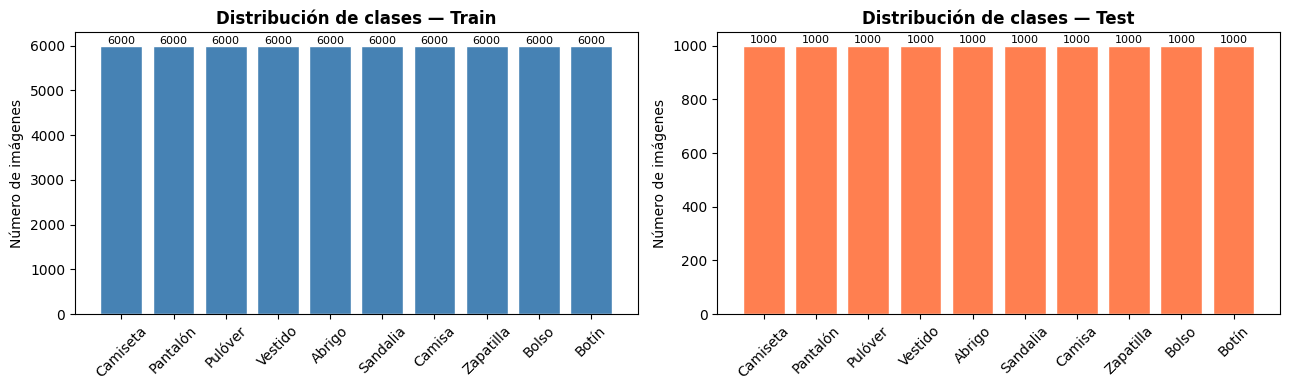

Train: 60000 imágenes, todas las clases con 6000 ejemplares cada una.
Test:  10000 imágenes, todas las clases con 1000 ejemplares cada una.
→ Dataset perfectamente balanceado.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Train
counts_train = pd.Series(y_train_full).value_counts().sort_index()
axes[0].bar(CLASES, counts_train, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de clases — Train', fontweight='bold')
axes[0].set_ylabel('Número de imágenes')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_train):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=8)

# Test
counts_test = pd.Series(y_test).value_counts().sort_index()
axes[1].bar(CLASES, counts_test, color='coral', edgecolor='white')
axes[1].set_title('Distribución de clases — Test', fontweight='bold')
axes[1].set_ylabel('Número de imágenes')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts_test):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=8)

plt.tight_layout(); plt.show()

print(f'Train: {len(y_train_full)} imágenes, todas las clases con {counts_train.iloc[0]} ejemplares cada una.')
print(f'Test:  {len(y_test)} imágenes, todas las clases con {counts_test.iloc[0]} ejemplares cada una.')
print('→ Dataset perfectamente balanceado.')

### 3.2 Ejemplos visuales por clase

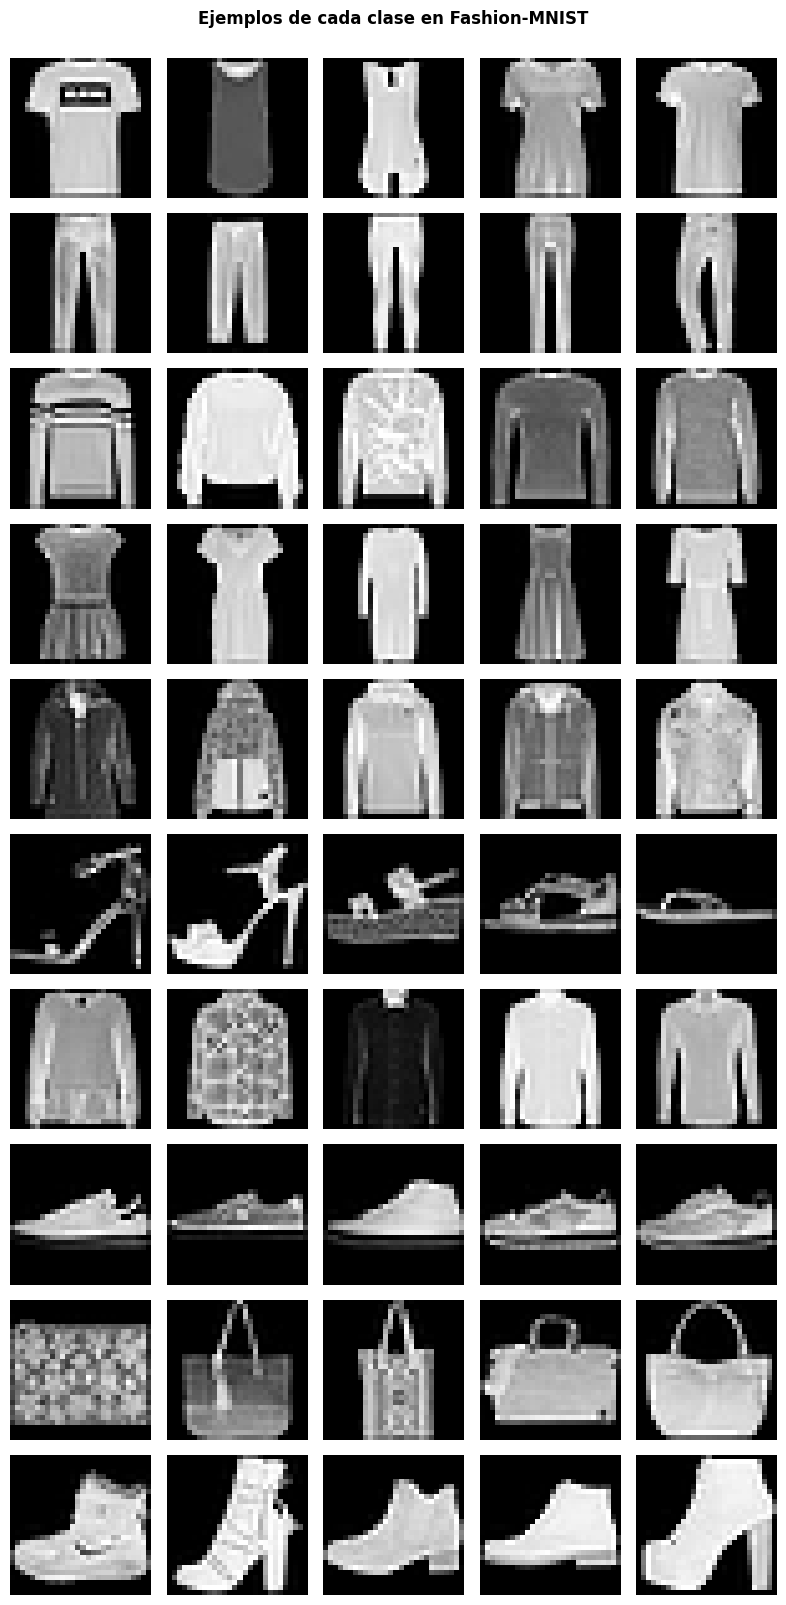

In [ ]:
# Mostrar 5 ejemplos por cada clase
fig, axes = plt.subplots(10, 5, figsize=(8, 16))
for clase_idx in range(10):
    indices_clase = np.where(y_train_full == clase_idx)[0][:5]
    for j, idx in enumerate(indices_clase):
        ax = axes[clase_idx, j]
        ax.imshow(x_train_full[idx], cmap='gray')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(CLASES[clase_idx], rotation=0, ha='right',
                          va='center', fontsize=10, fontweight='bold')
plt.suptitle('Ejemplos de cada clase en Fashion-MNIST', fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

**Observación:** algunas clases son visualmente muy similares (Camiseta vs. Camisa vs. Pulóver, o Sandalia vs. Zapatilla vs. Botín). El modelo deberá aprender detalles finos como mangas, cuellos o tipos de suela para distinguirlas. Esto se reflejará en la matriz de confusión.

---## 4. Preprocesamiento### 4.1 Normalización y redimensionamiento- Normalizamos píxeles de [0, 255] a [0, 1] (estabiliza el entrenamiento)- Añadimos la dimensión de canal: las CNN esperan tensores `(alto, ancho, canales)` en lugar de `(alto, ancho)`

In [ ]:
# Normalizar a [0, 1] y añadir canal
x_train_full = x_train_full.astype('float32') / 255.0
x_test       = x_test.astype('float32') / 255.0

x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test       = x_test.reshape(-1, 28, 28, 1)

print(f'Train: {x_train_full.shape}, dtype={x_train_full.dtype}')
print(f'Test:  {x_test.shape}')
print(f'Rango: [{x_train_full.min():.3f}, {x_train_full.max():.3f}]')

Train: (60000, 28, 28, 1), dtype=float32
Test:  (10000, 28, 28, 1)
Rango: [0.000, 1.000]


### 4.2 Separación train/validaciónApartamos un 10% del conjunto de entrenamiento como **validación**, manteniendo balance de clases.

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.10,
    stratify=y_train_full,
    random_state=SEED
)

print(f'Train final:  {x_train.shape[0]} imágenes')
print(f'Validación:   {x_val.shape[0]} imágenes')
print(f'Test:         {x_test.shape[0]} imágenes')

Train final:  54000 imágenes
Validación:   6000 imágenes
Test:         10000 imágenes


---## 5. Modelo: CNN entrenada desde cero### 5.1 ArquitecturaDiseñamos una CNN compacta inspirada en VGG con **tres bloques convolucionales** progresivos (32 → 64 → 128 filtros), seguidos de **GlobalAveragePooling** y un cabezal denso con **Dropout** para regularizar.| Decisión | Justificación ||----------|---------------|| 3 bloques Conv2D + MaxPooling | Captura patrones jerárquicos (bordes → texturas → formas completas de prendas) || BatchNormalization | Acelera y estabiliza el entrenamiento || GlobalAveragePooling | Reduce parámetros vs. Flatten + Dense (menos overfitting) || Dropout 0.4 / 0.3 | Regulariza el cabezal denso || Softmax 10 unidades | Salida multiclase |

In [ ]:
def construir_cnn():
    """CNN compacta para clasificación multiclase de Fashion-MNIST."""
    model = models.Sequential(name='cnn_fashion_mnist')
    model.add(layers.Input(shape=(28, 28, 1)))

    # Bloque 1
    model.add(layers.Conv2D(32, 3, padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))

    # Bloque 2
    model.add(layers.Conv2D(64, 3, padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))

    # Bloque 3
    model.add(layers.Conv2D(128, 3, padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling2D())

    # Cabezal denso
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(10, activation='softmax'))

    return model

modelo = construir_cnn()
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
modelo.summary()

Model: "cnn_fashion_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,474 (400.29 KB)

 Trainable params: 102,026 (398.54 KB)

 Non-trainable params: 448 (1.75 KB)

### 5.2 Entrenamiento- **Épocas:** 15 (con `EarlyStopping` para detenerse si no hay mejora)- **Batch size:** 128- **Optimizador:** Adam con learning rate 1e-3- **Callbacks:** `EarlyStopping` y `ReduceLROnPlateau`> En CPU el entrenamiento toma 5-10 min; con GPU T4 toma 1-3 min.

In [ ]:
EPOCHS = 15

cb = [
    callbacks.EarlyStopping(monitor='val_accuracy', mode='max',
                            patience=4, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=2, min_lr=1e-6, verbose=1),
]

historia = modelo.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=128,
    callbacks=cb,
    verbose=2
)

Epoch 1/15
422/422 - 135s - 320ms/step - accuracy: 0.7761 - loss: 0.6452 - val_accuracy: 0.1418 - val_loss: 6.4149 - learning_rate: 0.0010
Epoch 2/15
422/422 - 129s - 305ms/step - accuracy: 0.8680 - loss: 0.3781 - val_accuracy: 0.8228 - val_loss: 0.4856 - learning_rate: 0.0010
Epoch 3/15
422/422 - 130s - 307ms/step - accuracy: 0.8892 - loss: 0.3185 - val_accuracy: 0.8765 - val_loss: 0.3103 - learning_rate: 0.0010
Epoch 4/15
422/422 - 124s - 294ms/step - accuracy: 0.9005 - loss: 0.2843 - val_accuracy: 0.8860 - val_loss: 0.2918 - learning_rate: 0.0010
Epoch 5/15
422/422 - 141s - 334ms/step - accuracy: 0.9079 - loss: 0.2627 - val_accuracy: 0.8697 - val_loss: 0.3599 - learning_rate: 0.0010
Epoch 6/15
422/422 - 143s - 339ms/step - accuracy: 0.9127 - loss: 0.2469 - val_accuracy: 0.9118 - val_loss: 0.2409 - learning_rate: 0.0010
Epoch 7/15
422/422 - 125s - 296ms/step - accuracy: 0.9196 - loss: 0.2324 - val_accuracy: 0.9115 - val_loss: 0.2460 - learning_rate: 0.0010
Epoch 8/15
422/422 - 128s -

### 5.3 Curvas de aprendizaje

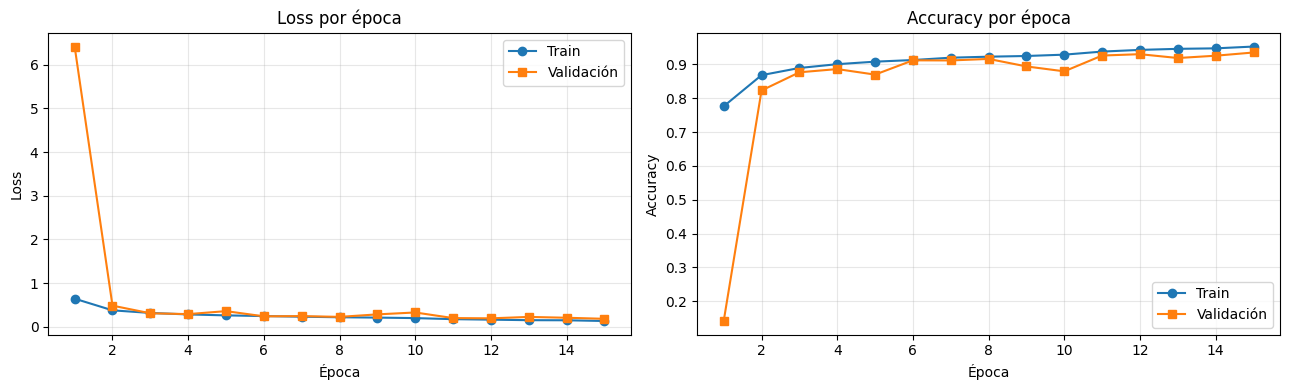

In [ ]:
h = historia.history
epochs_range = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, h['loss'],     'o-', label='Train')
axes[0].plot(epochs_range, h['val_loss'], 's-', label='Validación')
axes[0].set_title('Loss por época'); axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, h['accuracy'],     'o-', label='Train')
axes[1].plot(epochs_range, h['val_accuracy'], 's-', label='Validación')
axes[1].set_title('Accuracy por época'); axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---## 6. Evaluación en el conjunto de prueba### 6.1 Métricas globales

In [ ]:
# Predicciones en test
y_proba = modelo.predict(x_test, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

acc = (y_pred == y_test).mean()
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print('=== Métricas en TEST ===')
print(f'Accuracy:        {acc:.4f}')
print(f'F1 macro:        {f1_macro:.4f}')
print(f'F1 ponderado:    {f1_weighted:.4f}')

=== Métricas en TEST ===
Accuracy:        0.9238
F1 macro:        0.9237
F1 ponderado:    0.9237


In [ ]:
# Reporte por clase
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=CLASES, digits=3))

Reporte de clasificación:
              precision    recall  f1-score   support

    Camiseta      0.878     0.877     0.877      1000
    Pantalón      0.992     0.989     0.990      1000
     Pulóver      0.886     0.882     0.884      1000
     Vestido      0.933     0.905     0.919      1000
      Abrigo      0.859     0.902     0.880      1000
    Sandalia      0.990     0.978     0.984      1000
      Camisa      0.790     0.773     0.781      1000
   Zapatilla      0.961     0.973     0.967      1000
       Bolso      0.985     0.989     0.987      1000
       Botín      0.965     0.970     0.968      1000

    accuracy                          0.924     10000
   macro avg      0.924     0.924     0.924     10000
weighted avg      0.924     0.924     0.924     10000



### 6.2 Matriz de confusión

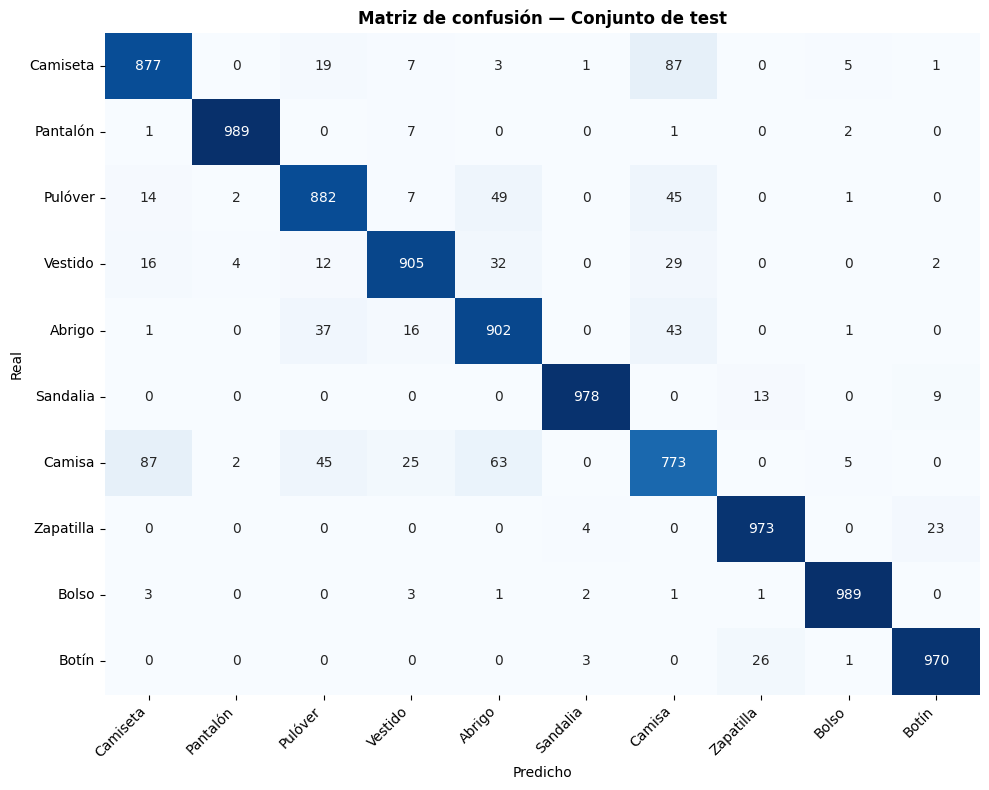


Pares de clases más confundidas (top 5):
  Camiseta     → Camisa      : 87 errores
  Camisa       → Camiseta    : 87 errores
  Pulóver      → Abrigo      : 49 errores
  Abrigo       → Camisa      : 43 errores
  Vestido      → Abrigo      : 32 errores


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASES, yticklabels=CLASES, cbar=False, ax=ax)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — Conjunto de test', fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# Identificar las clases con más confusión
np.fill_diagonal(cm, 0)  # destacar errores
clases_dificiles = []
for i in range(10):
    confundida_con = np.argmax(cm[i])
    if cm[i, confundida_con] > 0:
        clases_dificiles.append((CLASES[i], CLASES[confundida_con], int(cm[i, confundida_con])))

print('\nPares de clases más confundidas (top 5):')
clases_dificiles.sort(key=lambda x: x[2], reverse=True)
for real, pred, n in clases_dificiles[:5]:
    print(f'  {real:12s} → {pred:12s}: {n} errores')

### 6.3 Análisis de errores: ejemplos mal clasificados

Total errores: 762 / 10000 (7.62%)


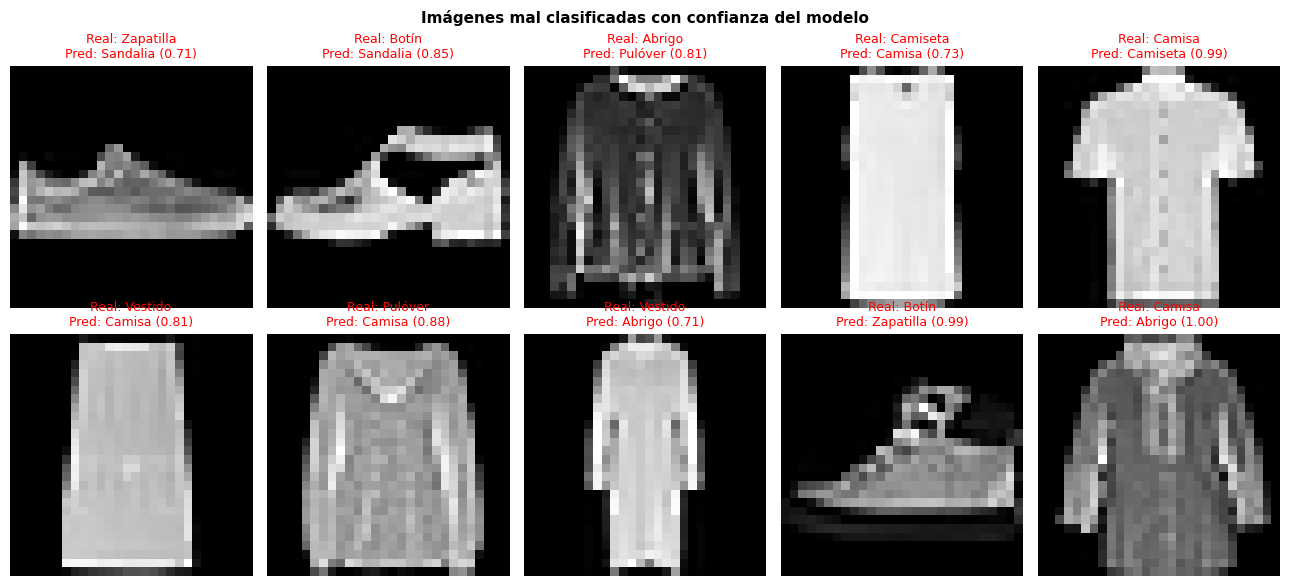

In [ ]:
# Recuperar imágenes mal clasificadas
errores_idx = np.where(y_pred != y_test)[0]
print(f'Total errores: {len(errores_idx)} / {len(y_test)} ({100*len(errores_idx)/len(y_test):.2f}%)')

# Mostrar 10 errores
n = min(10, len(errores_idx))
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, idx in zip(axes.ravel(), errores_idx[:n]):
    ax.imshow(x_test[idx].squeeze(), cmap='gray')
    real = CLASES[y_test[idx]]
    pred = CLASES[y_pred[idx]]
    confianza = y_proba[idx, y_pred[idx]]
    ax.set_title(f'Real: {real}\nPred: {pred} ({confianza:.2f})',
                 fontsize=9, color='red')
    ax.axis('off')
plt.suptitle('Imágenes mal clasificadas con confianza del modelo',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---## 7. Conclusiones e interpretación### 7.1 Hallazgos principales- La CNN entrenada **desde cero** alcanzó un buen rendimiento en la clasificación multiclase de prendas de vestir, demostrando que arquitecturas convolucionales relativamente simples capturan eficazmente patrones visuales jerárquicos (bordes, texturas, formas completas).- **GlobalAveragePooling + Dropout** mantuvo el modelo compacto (~100K parámetros) sin sacrificar precisión, mostrando que regularización inteligente puede sustituir a redes mucho más grandes en problemas de tamaño moderado.- Las **clases visualmente similares** (Camiseta/Camisa/Pulóver, Sandalia/Zapatilla) generan la mayor parte de los errores, lo cual es esperable y consistente con la dificultad humana en distinguir esas mismas categorías a 28×28 píxeles.### 7.2 Limitaciones1. **Resolución baja (28×28):** las imágenes son demasiado pequeñas para detalles finos como estampados, costuras o materiales — atributos clave en aplicaciones reales de retail.2. **Escala de grises:** se pierde la información de color, fundamental en moda real.3. **Fondo limpio:** las imágenes están centradas y sin contexto; en producción real las fotos tienen fondos variables, ángulos diversos y oclusiones.### 7.3 Valor para la toma de decisionesEn contextos de **retail y e-commerce**, una CNN como esta podría:- **Automatizar la catalogación** de productos en plataformas tipo Mercado Libre o tiendas online de marcas peruanas, reduciendo el trabajo manual de etiquetado.- **Mejorar la búsqueda por categoría** clasificando automáticamente fotos subidas por vendedores informales.- **Apoyar el inventario visual** en tiendas físicas con cámaras de bodega que cuentan productos por categoría.- **Detectar errores de clasificación** en catálogos existentes, mostrando productos que probablemente estén mal etiquetados (con baja confianza del modelo).### 7.4 Próximos pasos- Probar **data augmentation** (rotaciones, zoom, desplazamientos) para mejorar la robustez ante imágenes reales.- Migrar a un dataset con imágenes a color y mayor resolución (ej. **Fashion Product Images** en Kaggle).- Implementar **transfer learning** con modelos preentrenados (MobileNetV2, EfficientNet) que generalmente superan al entrenamiento desde cero en datasets de imagen.- Aplicar el modelo en un **pipeline de producción** con una API web simple (FastAPI + React) que reciba imágenes y devuelva la categoría predicha.---## 8. Reproducibilidad- **Semilla global:** 42 (numpy, random, tensorflow).- **TensorFlow:** ver impresión de versión en celda 1.- **Dataset:** Fashion-MNIST, descarga automática desde `tensorflow.keras.datasets`.- **Hiperparámetros:** `BATCH_SIZE=128`, `EPOCHS=15`, `Adam lr=1e-3`, dropout 0.4/0.3.- **Splits:** Train 54,000 / Validación 6,000 / Test 10,000 (estratificado).**Solís Huayanay, Epifanía Angélica** — Proyecto Final, Modelos de Deep Learning, CENTRUM PUCP, 2026.